# CT Lung Cancer Detection — Progress Report

**Task:** 4-class CT image classification  
**Classes:** Adenocarcinoma · Squamous Cell Carcinoma · Large Cell Carcinoma · Normal  
**Dataset:** 988 PNG CT slices (601 train / 72 valid / 315 test)  
**Framework:** PyTorch + timm  
**Scope:** MS Thesis

---
**Contents**
1. Setup & Data Loading
2. Dataset Overview
3. Data Validation
4. Experiment Configurations


## 1. Setup & Data Loading

In [13]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yaml
from PIL import Image

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Project root is the notebook directory
ROOT = Path('.')
sys.path.insert(0, str(ROOT))

from tools.data.class_map import CLASSES, CLASS_TO_IDX, DISPLAY_NAMES, TRAIN_FOLDER_MAP

# Load experiment data
#with open(ROOT / 'models/baseline_v1.json') as f:
   # run1_meta = json.load(f)
#with open(ROOT / 'models/efficientnet_focal_v1.json') as f:
   # run2_meta = json.load(f)
#with open(ROOT / 'reports/eval_baseline_v1.json') as f:
    #run1_eval = json.load(f)
#with open(ROOT / 'reports/eval_efficientnet_focal_v1.json') as f:
    #run2_eval = json.load(f)
#with open(ROOT / 'reports/eval_efficientnet_focal_v1.json') as f:
   # run2_eval = json.load(f)
#with open(ROOT / 'experiments/efficientnet_focal_v1/gradcam/gradcam_summary.json') as f:
   # gradcam_summary = json.load(f)
#with open(ROOT / 'args/train.yaml') as f:
    #cfg = yaml.safe_load(f)

DISPLAY = [DISPLAY_NAMES[c] for c in CLASSES]
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
print('All artifacts loaded successfully.')

All artifacts loaded successfully.


## 2. Dataset Overview

In [17]:

# Class distribution across splits
from tools.training.dataset import CTLungDataset, compute_class_weights

train_ds = CTLungDataset('Data-2', 'train', 224, cfg)
valid_ds = CTLungDataset('Data-2', 'valid', 224, cfg)
test_ds  = CTLungDataset('Data-2', 'test',  224, cfg)

splits = {'Train': train_ds, 'Valid': valid_ds, 'Test': test_ds}
counts = {split: [ds.class_counts[c] for c in CLASSES] for split, ds in splits.items()}

# Bar chart
x = np.arange(len(CLASSES))
width = 0.25   
fig, ax = plt.subplots(figsize=(10, 4))
for i, (split, cnt) in enumerate(counts.items()):
    bars = ax.bar(x + i * width, cnt, width, label=split, color=['#4878CF','#6ACC65','#D65F5F'][i], alpha=0.85)
    for bar, v in zip(bars, cnt):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, str(v),
                ha='center', va='bottom', fontsize=9)
ax.set_xticks(x + width)
ax.set_xticklabels(DISPLAY, fontsize=10)
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution Across Splits')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Class":<30} {"Train":>6} {"Valid":>6} {"Test":>6} {"Total":>7}')
print('-' * 58)
for i, (cls, disp) in enumerate(zip(CLASSES, DISPLAY)):
    t, v, te = counts['Train'][i], counts['Valid'][i], counts['Test'][i]
    print(f'{disp:<30} {t:>6} {v:>6} {te:>6} {t+v+te:>7}')
print('-' * 58)
print(f'{"TOTAL":<30} {sum(counts["Train"]):>6} {sum(counts["Valid"]):>6} {sum(counts["Test"]):>6} {988:>7}')

ModuleNotFoundError: No module named 'torch'

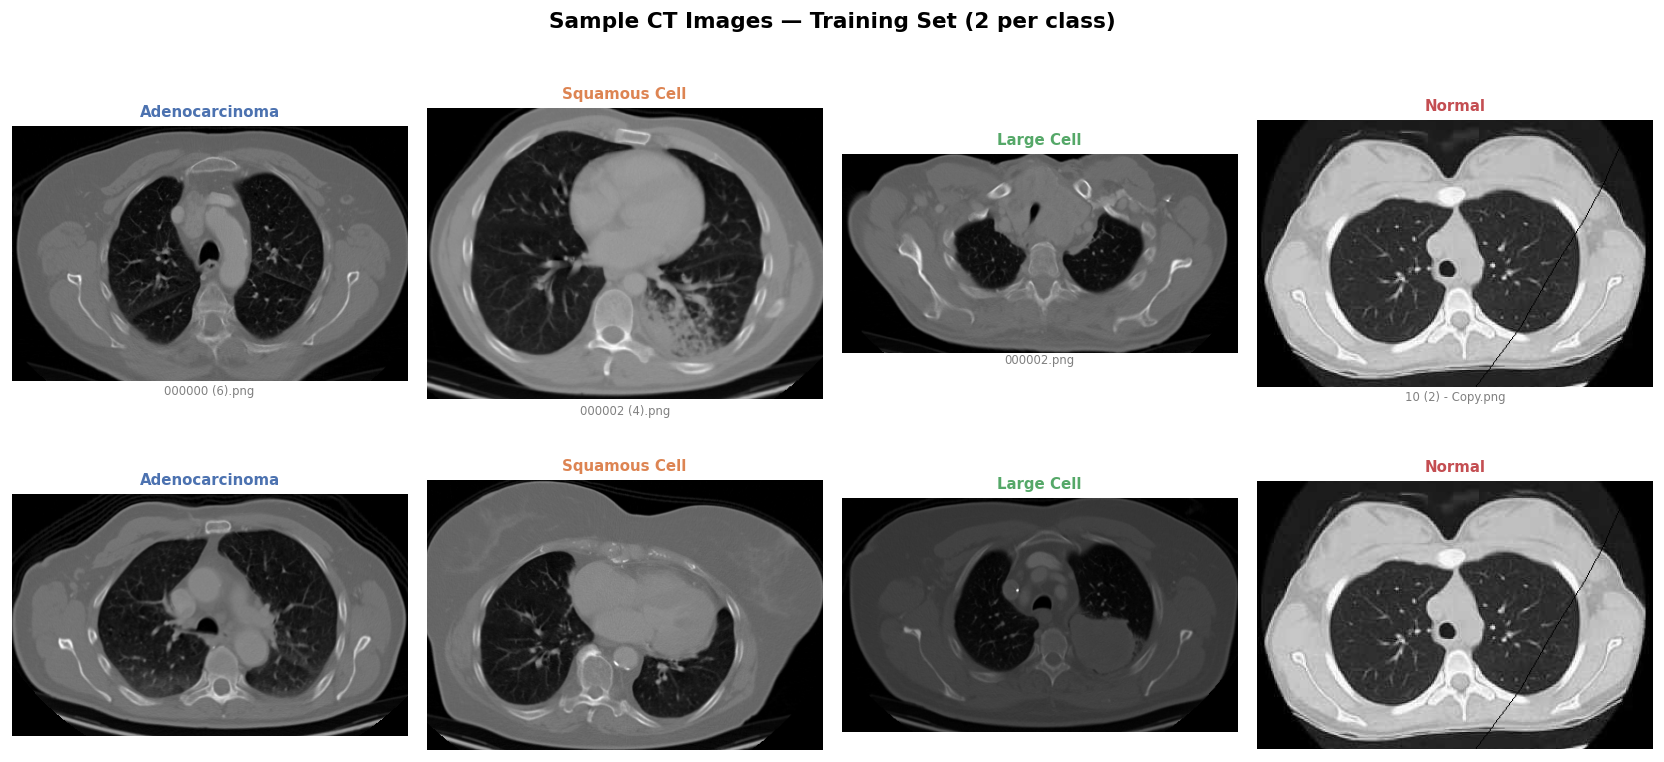

In [ ]:
# Sample images: 2 per class from training set
data_root = ROOT / 'Data-2' / 'train'
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample CT Images — Training Set (2 per class)', fontsize=13, fontweight='bold')

for col, (folder, canonical) in enumerate(TRAIN_FOLDER_MAP.items()):
    folder_path = data_root / folder
    images = sorted(folder_path.glob('*.png'))[:2]
    for row, img_path in enumerate(images):
        ax = axes[row][col]
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img, cmap='gray')
        ax.set_title(DISPLAY_NAMES[canonical], fontsize=9, fontweight='bold', color=COLORS[col])
        ax.axis('off')
        if row == 0:
            ax.text(0.5, -0.05, img_path.name, transform=ax.transAxes,
                    ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

In [ ]:
# Class weights for weighted loss
weights = compute_class_weights(train_ds)
print('Class Weights (Weighted CrossEntropyLoss / FocalLoss):')
print(f'{"Class":<30} {"Train Count":>12} {"Weight":>10}')
print('-' * 55)
for disp, cls, w in zip(DISPLAY, CLASSES, weights.tolist()):
    cnt = train_ds.class_counts[cls]
    print(f'{disp:<30} {cnt:>12} {w:>10.4f}')
print('\nHigher weight = model penalised more for misclassifying that class.')

Class Weights (Weighted CrossEntropyLoss / FocalLoss):
Class                           Train Count     Weight
-------------------------------------------------------
Adenocarcinoma                          195     0.7705
Squamous Cell                           155     0.9694
Large Cell                              115     1.3065
Normal                                  136     1.1048

Higher weight = model penalised more for misclassifying that class.


## 3. Data Validation

In [ ]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, 'tools/data/validate_data.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-500:])

CT Lung Cancer Dataset Validation

[TRAIN] — 601 images
  adenocarcinoma                  195   32.4%  ████████████████
  squamous_cell_carcinoma         155   25.8%  ████████████
  large_cell_carcinoma            115   19.1%  █████████
  normal                          136   22.6%  ███████████

[VALID] — 72 images
  adenocarcinoma                   23   31.9%  ███████████████
  squamous_cell_carcinoma          15   20.8%  ██████████
  large_cell_carcinoma             21   29.2%  ██████████████
  normal                           13   18.1%  █████████

[TEST] — 315 images
  adenocarcinoma                  120   38.1%  ███████████████████
  squamous_cell_carcinoma          90   28.6%  ██████████████
  large_cell_carcinoma             51   16.2%  ████████
  normal                           54   17.1%  ████████

[LEAKAGE CHECK] Train vs Test patient overlap

[CLASS WEIGHTS] (for weighted CrossEntropyLoss)
  adenocarcinoma                  count=195  weight=0.7705
  squamous_cell_carcinoma 

> **Note on Patient-Level Leakage:** The pre-defined split was made at the CT **slice level**, not the **patient level**. 22 patients have slices in both `train/` and `test/`. This is the **standard published split** for this dataset — using it maintains comparability with existing literature. Documented as a thesis limitation.

## 4. Experiment Configurations

In [ ]:
import pandas as pd

r1cfg = run1_meta['config']
r2cfg = run2_meta['config']

config_rows = [
    ('Backbone',           r1cfg['model']['backbone'],          r2cfg['model']['backbone']),
    ('Pretrained',         str(r1cfg['model']['pretrained']),   str(r2cfg['model']['pretrained'])),
    ('Dropout',            r1cfg['model']['dropout'],           r2cfg['model']['dropout']),
    ('Loss function',      r1cfg['training']['loss'],           r2cfg['training']['loss']),
    ('Focal gamma',        '—',                                 r2cfg['training'].get('focal_gamma','—')),
    ('Learning rate',      r1cfg['training']['lr'],             r2cfg['training']['lr']),
    ('Batch size',         r1cfg['training']['batch_size'],     r2cfg['training']['batch_size']),
    ('Scheduler',          r1cfg['training']['scheduler'],      r2cfg['training']['scheduler']),
    ('Early stop patience',r1cfg['training']['early_stopping_patience'], r2cfg['training']['early_stopping_patience']),
    ('Image size',         r1cfg['data']['image_size'],         r2cfg['data']['image_size']),
    ('Rotation aug',       r1cfg['augmentation']['random_rotation'], r2cfg['augmentation']['random_rotation']),
    ('Seed',               r1cfg['training']['seed'],           r2cfg['training']['seed']),
]

df = pd.DataFrame(config_rows, columns=['Parameter', 'Run 1 — ResNet-50', 'Run 2 — EfficientNet-B0'])
df = df.set_index('Parameter')

# Highlight rows that differ
def highlight_diff(row):
    return ['background-color: #fff3cd' if row.iloc[0] != row.iloc[1] else '' for _ in row]

df.style.apply(highlight_diff, axis=1).set_caption('Highlighted rows differ between runs')

,Run 1 — ResNet-50,Run 2 — EfficientNet-B0
Parameter,,
Backbone,resnet50,efficientnet_b0
Pretrained,True,True
Dropout,0.500000,0.400000
Loss function,weighted_ce,focal
Focal gamma,—,2.000000
Learning rate,0.000100,0.000100
Batch size,32,32
Scheduler,cosine,cosine
Early stop patience,7,10
